In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from natsort import natsorted
import scanpy as sc

import torch
import os
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.set_printoptions(suppress=True)

%reload_ext autoreload
%autoreload 2

### Table of all best fit parameters (Cord Blood) Day 3

In [2]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/v1.2.0/checkpoints/CordBloodDynamicRates/1213_100718/model_last.pt'
model = torch.load(path, map_location='cpu')
device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [17]:
from itertools import product

anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))
graph = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['graphs']
), index_col=0)
np.fill_diagonal(graph.values, 1)

cols = []
for pop1, pop2 in product(range(graph.shape[0]), range(graph.shape[1])):
    if graph.values[pop1][pop2] != 0:
        cols.append('{} -> {}'.format(anno['populations'].values[pop1], anno['populations'].values[pop2]))

In [36]:
from clonaltrans.utils import get_post_masks
tpoint = 3.0

K_type = model.config['arch']['args']['K_type']
K = model.get_matrix_K(K_type=K_type, eval=True, tpoint=tpoint).detach().cpu().numpy()

masks = get_post_masks(model, tpoint)
K[masks[0], masks[1], :] = 0

indices = np.argwhere(graph == 1)
K_existed = np.array([K[i, indices[:, 0], indices[:, 1]] for i in range(K.shape[0])])

In [37]:
df = pd.DataFrame(K_existed.T, index=cols, columns=anno['clones'].values[:-1]).round(3)
df

,Clone 0,Clone 1,Clone 2,Clone 3,Clone 4,Clone 5,Clone 6,Clone 7,Clone 8,Clone 10,Clone BG
HSC/MPP 1 -> HSC/MPP 1,0.815,0.000,0.382,0.000,0.187,1.204,0.340,1.263,0.000,0.000,1.369
HSC/MPP 1 -> HSC/MPP 2,0.165,0.000,0.065,0.000,0.016,0.209,0.044,0.568,0.000,0.000,0.329
HSC/MPP 1 -> MEMP,0.134,0.000,0.154,0.000,0.076,0.004,0.032,0.134,0.000,0.000,0.123
HSC/MPP 1 -> DC precursor,0.107,0.000,0.005,0.000,0.009,0.127,0.022,0.143,0.000,0.000,0.098
HSC/MPP 2 -> HSC/MPP 2,0.347,0.000,1.300,0.000,1.241,0.040,0.478,0.933,0.000,0.837,0.715
HSC/MPP 2 -> MEMP,0.059,0.000,0.008,0.000,0.100,0.000,0.063,0.078,0.000,0.000,0.052
HSC/MPP 2 -> NMP,0.039,0.000,0.011,0.000,0.430,0.234,0.005,0.156,0.000,0.204,0.095
HSC/MPP 2 -> Mono precur,0.021,0.000,0.057,0.000,0.006,0.012,0.004,0.121,0.000,0.036,0.063
HSC/MPP 2 -> DC precursor,0.000,0.000,0.179,0.000,0.019,0.025,0.015,0.001,0.000,0.000,0.003
MEMP -> MEMP,0.808,0.927,0.006,0.520,0.194,0.017,0.282,1.165,0.786,0.000,0.979


In [38]:
df.to_csv('table_of_best_fit_cordblood_day3.csv')

### Table of all best fit parameters (Cord Blood) Day 10

In [40]:
from clonaltrans.utils import get_post_masks
tpoint = 10.0

K_type = model.config['arch']['args']['K_type']
K = model.get_matrix_K(K_type=K_type, eval=True, tpoint=tpoint).detach().cpu().numpy()

masks = get_post_masks(model, tpoint)
K[masks[0], masks[1], :] = 0

indices = np.argwhere(graph == 1)
K_existed = np.array([K[i, indices[:, 0], indices[:, 1]] for i in range(K.shape[0])])

In [41]:
df = pd.DataFrame(K_existed.T, index=cols, columns=anno['clones'].values[:-1]).round(3)
df

,Clone 0,Clone 1,Clone 2,Clone 3,Clone 4,Clone 5,Clone 6,Clone 7,Clone 8,Clone 10,Clone BG
HSC/MPP 1 -> HSC/MPP 1,0.881,0.000,0.356,0.000,0.152,0.832,0.358,1.197,0.000,0.000,0.624
HSC/MPP 1 -> HSC/MPP 2,0.588,0.000,0.232,0.000,0.032,1.223,0.144,1.068,0.000,0.000,0.994
HSC/MPP 1 -> MEMP,0.499,0.000,0.550,0.000,0.141,0.026,0.133,0.267,0.000,0.000,0.376
HSC/MPP 1 -> DC precursor,0.368,0.000,0.017,0.000,0.020,0.782,0.091,0.279,0.000,0.000,0.290
HSC/MPP 2 -> HSC/MPP 2,0.374,0.000,1.225,0.000,1.035,0.017,0.508,0.873,0.000,0.104,0.331
HSC/MPP 2 -> MEMP,0.183,0.000,0.029,0.000,0.208,0.000,0.221,0.152,0.000,0.000,0.145
HSC/MPP 2 -> NMP,0.143,0.000,0.035,0.000,0.907,1.427,0.023,0.285,0.000,0.420,0.250
HSC/MPP 2 -> Mono precur,0.082,0.000,0.194,0.000,0.013,0.066,0.011,0.221,0.000,0.142,0.189
HSC/MPP 2 -> DC precursor,0.000,0.000,0.641,0.000,0.042,0.177,0.058,0.002,0.000,0.000,0.005
MEMP -> MEMP,0.882,0.732,0.005,0.895,0.150,0.003,0.314,1.106,0.394,0.000,0.445


In [42]:
df.to_csv('table_of_best_fit_cordblood_day10.csv')

### Table of all best fit parameters (Cord Blood) Day 17

In [44]:
from clonaltrans.utils import get_post_masks
tpoint = 17.0

K_type = model.config['arch']['args']['K_type']
K = model.get_matrix_K(K_type=K_type, eval=True, tpoint=tpoint).detach().cpu().numpy()

masks = get_post_masks(model, tpoint)
K[masks[0], masks[1], :] = 0

indices = np.argwhere(graph == 1)
K_existed = np.array([K[i, indices[:, 0], indices[:, 1]] for i in range(K.shape[0])])

In [45]:
df = pd.DataFrame(K_existed.T, index=cols, columns=anno['clones'].values[:-1]).round(3)
df

,Clone 0,Clone 1,Clone 2,Clone 3,Clone 4,Clone 5,Clone 6,Clone 7,Clone 8,Clone 10,Clone BG
HSC/MPP 1 -> HSC/MPP 1,0.000,0.000,0.281,0.000,0.094,0.000,0.230,0.810,0.000,0.000,0.444
HSC/MPP 1 -> HSC/MPP 2,0.000,0.000,0.206,0.000,0.042,0.000,0.229,1.123,0.000,0.000,0.541
HSC/MPP 1 -> MEMP,0.000,0.000,0.499,0.000,0.172,0.000,0.218,0.283,0.000,0.000,0.207
HSC/MPP 1 -> DC precursor,0.000,0.000,0.016,0.000,0.028,0.000,0.149,0.295,0.000,0.000,0.159
HSC/MPP 2 -> HSC/MPP 2,0.288,0.000,0.963,0.000,0.648,0.002,0.325,0.590,0.000,0.035,0.236
HSC/MPP 2 -> MEMP,0.203,0.000,0.025,0.000,0.291,0.000,0.357,0.161,0.000,0.000,0.083
HSC/MPP 2 -> NMP,0.165,0.000,0.032,0.000,1.269,1.331,0.038,0.295,0.000,0.095,0.141
HSC/MPP 2 -> Mono precur,0.097,0.000,0.172,0.000,0.018,0.061,0.018,0.232,0.000,0.087,0.101
HSC/MPP 2 -> DC precursor,0.000,0.000,0.567,0.000,0.062,0.172,0.096,0.002,0.000,0.000,0.003
MEMP -> MEMP,0.686,0.729,0.003,0.837,0.092,0.001,0.203,0.747,0.346,0.000,0.317


In [46]:
df.to_csv('table_of_best_fit_cordblood_day17.csv')

### Pairwise comparison of all parameters (Cord Blood) Day 3

In [2]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/v1.2.0/checkpoints/CordBloodDynamicRates/1213_100718/model_last.pt'
model = torch.load(path, map_location='cpu')

device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [3]:
model_list = []

for name in tqdm(os.listdir("./trials/v1.2.0/checkpoints/CordBloodDynamicBoots/1213_115849/models")):
    if os.path.exists(os.path.join("./trials/v1.2.0/checkpoints/CordBloodDynamicBoots/1213_115849/models", name, f'{name}.pt')):
        model_list.append(torch.load(os.path.join(f"./trials/v1.2.0/checkpoints/CordBloodDynamicBoots/1213_115849/models", name, f'{name}.pt'), map_location='cuda:1'))

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:03<00:00, 151.16it/s]


In [13]:
from clonaltrans.utils import get_boots_K_total
tpoint = torch.tensor([3.0]).to('cpu')

K_type = model.config['arch']['args']['K_type']
total_K, ref_K = get_boots_K_total(model_list, model, K_type, tpoint)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [18]:
from clonaltrans.utils import clone_rates_diff_test

p_values, adjusted_p_values, fold_correct = clone_rates_diff_test(model, total_K, correct_method='fdr_bh')
print (p_values.shape, adjusted_p_values.shape, fold_correct.shape)

(55, 12, 12) (27, 55) (27, 55)


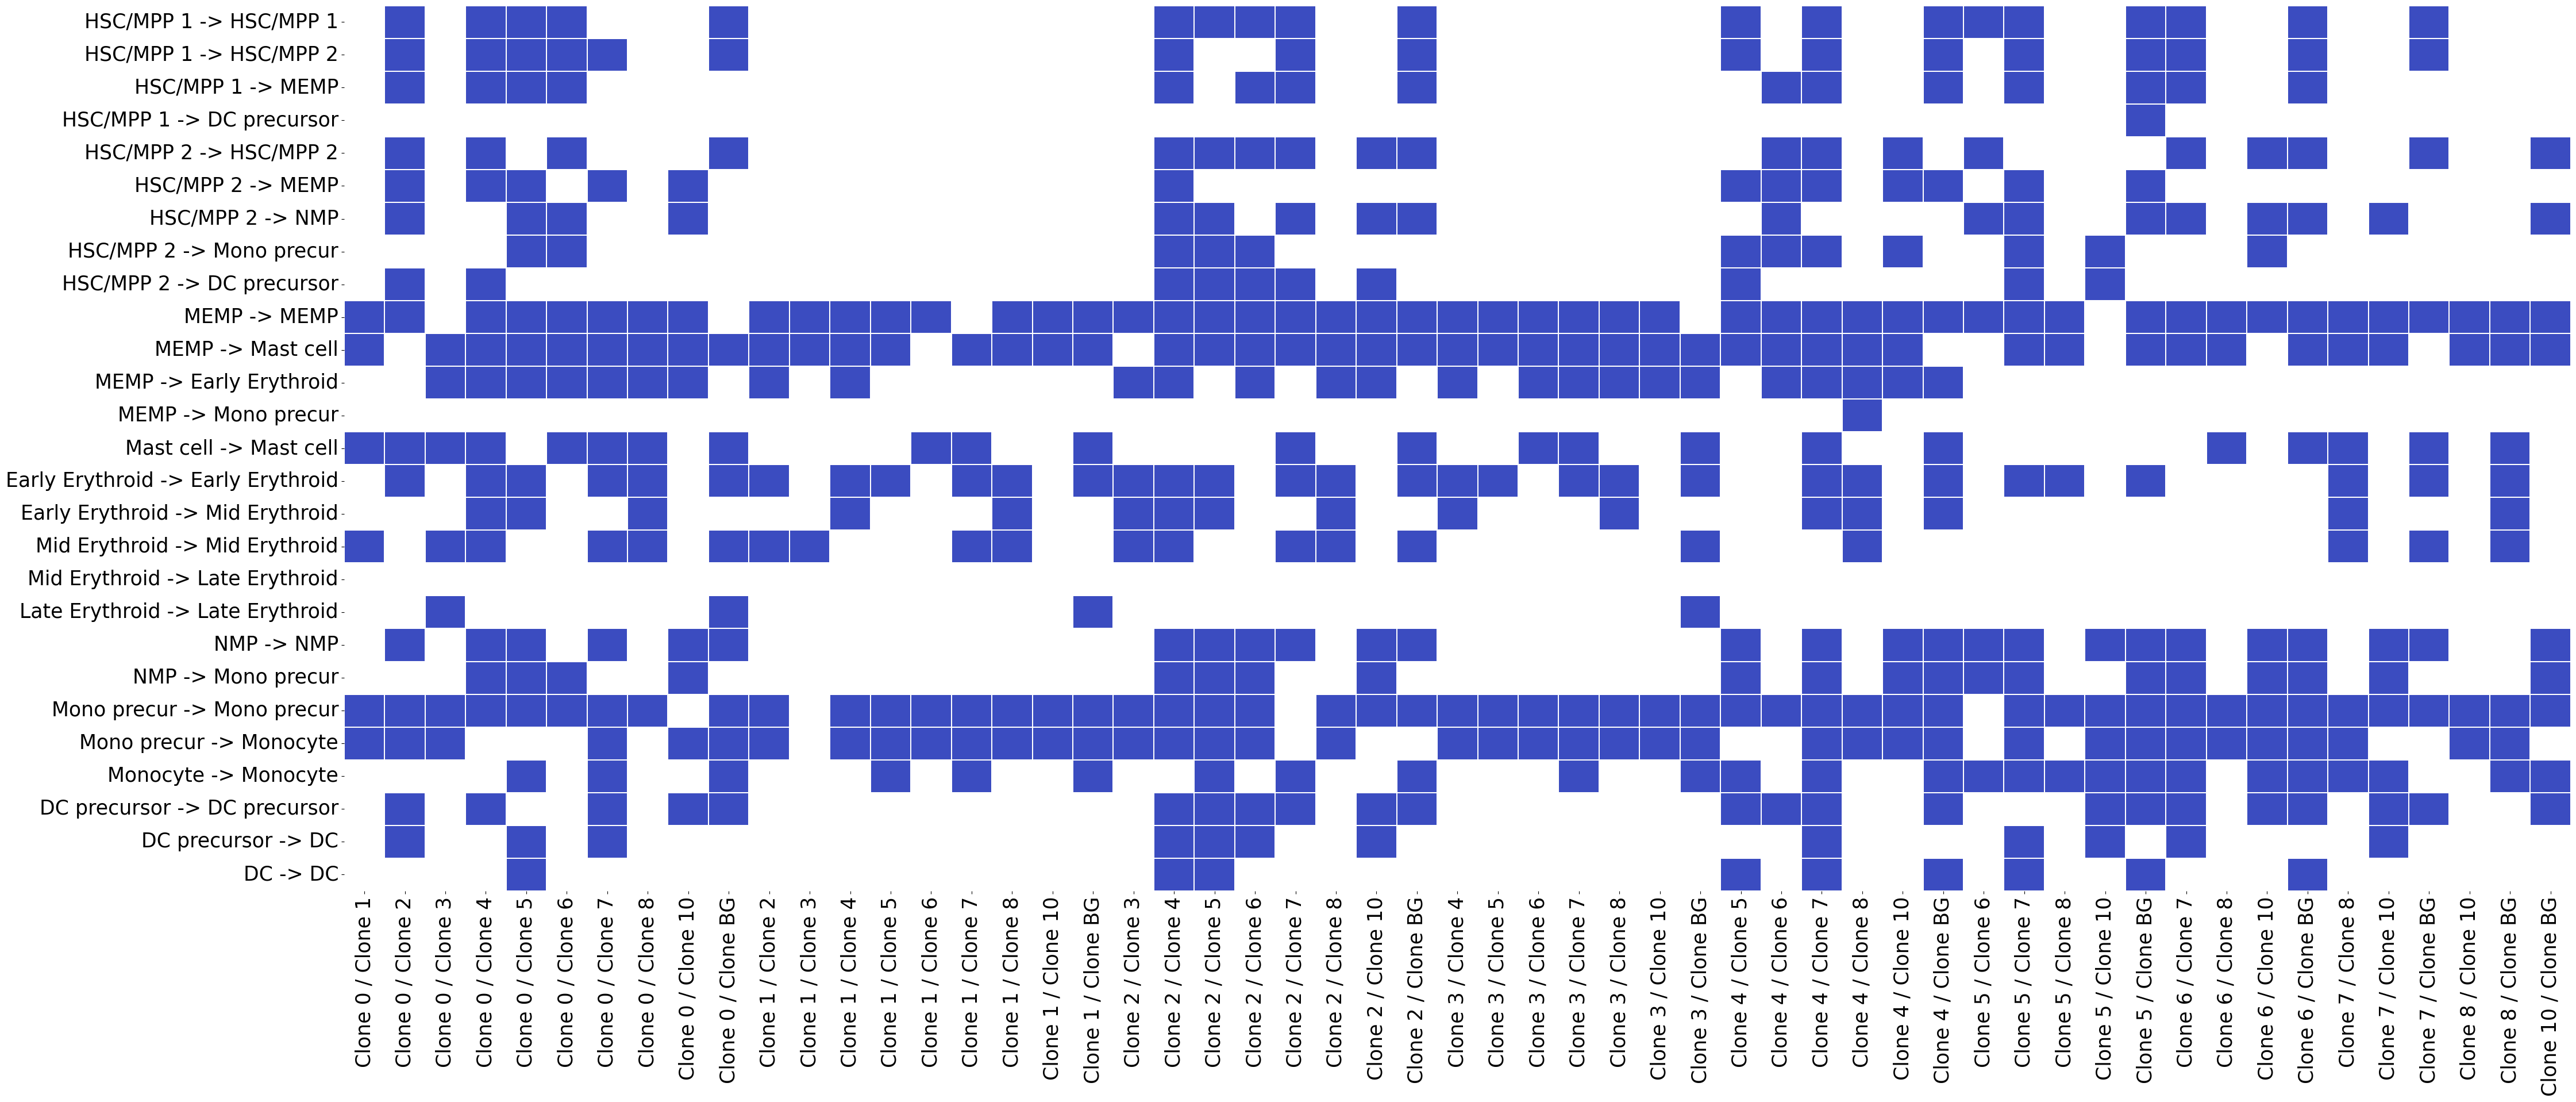

In [30]:
from itertools import product, combinations

combined = [adjusted_p_values, fold_correct]

anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))
graph = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['graphs']
), index_col=0)
np.fill_diagonal(graph.values, 1)
num_clones = model.N.shape[1]

cols = []
for pop1, pop2 in product(range(graph.shape[0]), range(graph.shape[1])):
    if graph.values[pop1][pop2] != 0:
        cols.append('{} -> {}'.format(anno['populations'].values[pop1], anno['populations'].values[pop2]))

index = []
for (c1, c2) in combinations(anno['clones'].values[:num_clones], 2):
    index.append(f'{c1} / {c2}')

combined[0][combined[0] > 0.01] = np.nan
combined[0][np.where(combined[1] < 0.1)] = np.nan
combined = -np.log10(combined[0])
combined[~np.isnan(combined)] = 0

df = pd.DataFrame(data=combined, index=cols, columns=index)
ax = sns.heatmap(df, annot=False, linewidths=.1, cmap='coolwarm', vmin=0, xticklabels=True, yticklabels=True, cbar=False)

plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(False)

fig = ax.get_figure()
fig.set_figwidth(50) 
fig.set_figheight(20) 

plt.savefig('pairwise_comparison_cordblood_day3.svg', bbox_inches='tight', transparent=True, dpi=300)

### Pairwise comparison of all parameters (Cord Blood) Day 10

In [31]:
from clonaltrans.utils import get_boots_K_total
tpoint = torch.tensor([10.0]).to('cpu')

K_type = model.config['arch']['args']['K_type']
total_K, ref_K = get_boots_K_total(model_list, model, K_type, tpoint)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [32]:
from clonaltrans.utils import clone_rates_diff_test

p_values, adjusted_p_values, fold_correct = clone_rates_diff_test(model, total_K, correct_method='fdr_bh')
print (p_values.shape, adjusted_p_values.shape, fold_correct.shape)

(55, 12, 12) (27, 55) (27, 55)


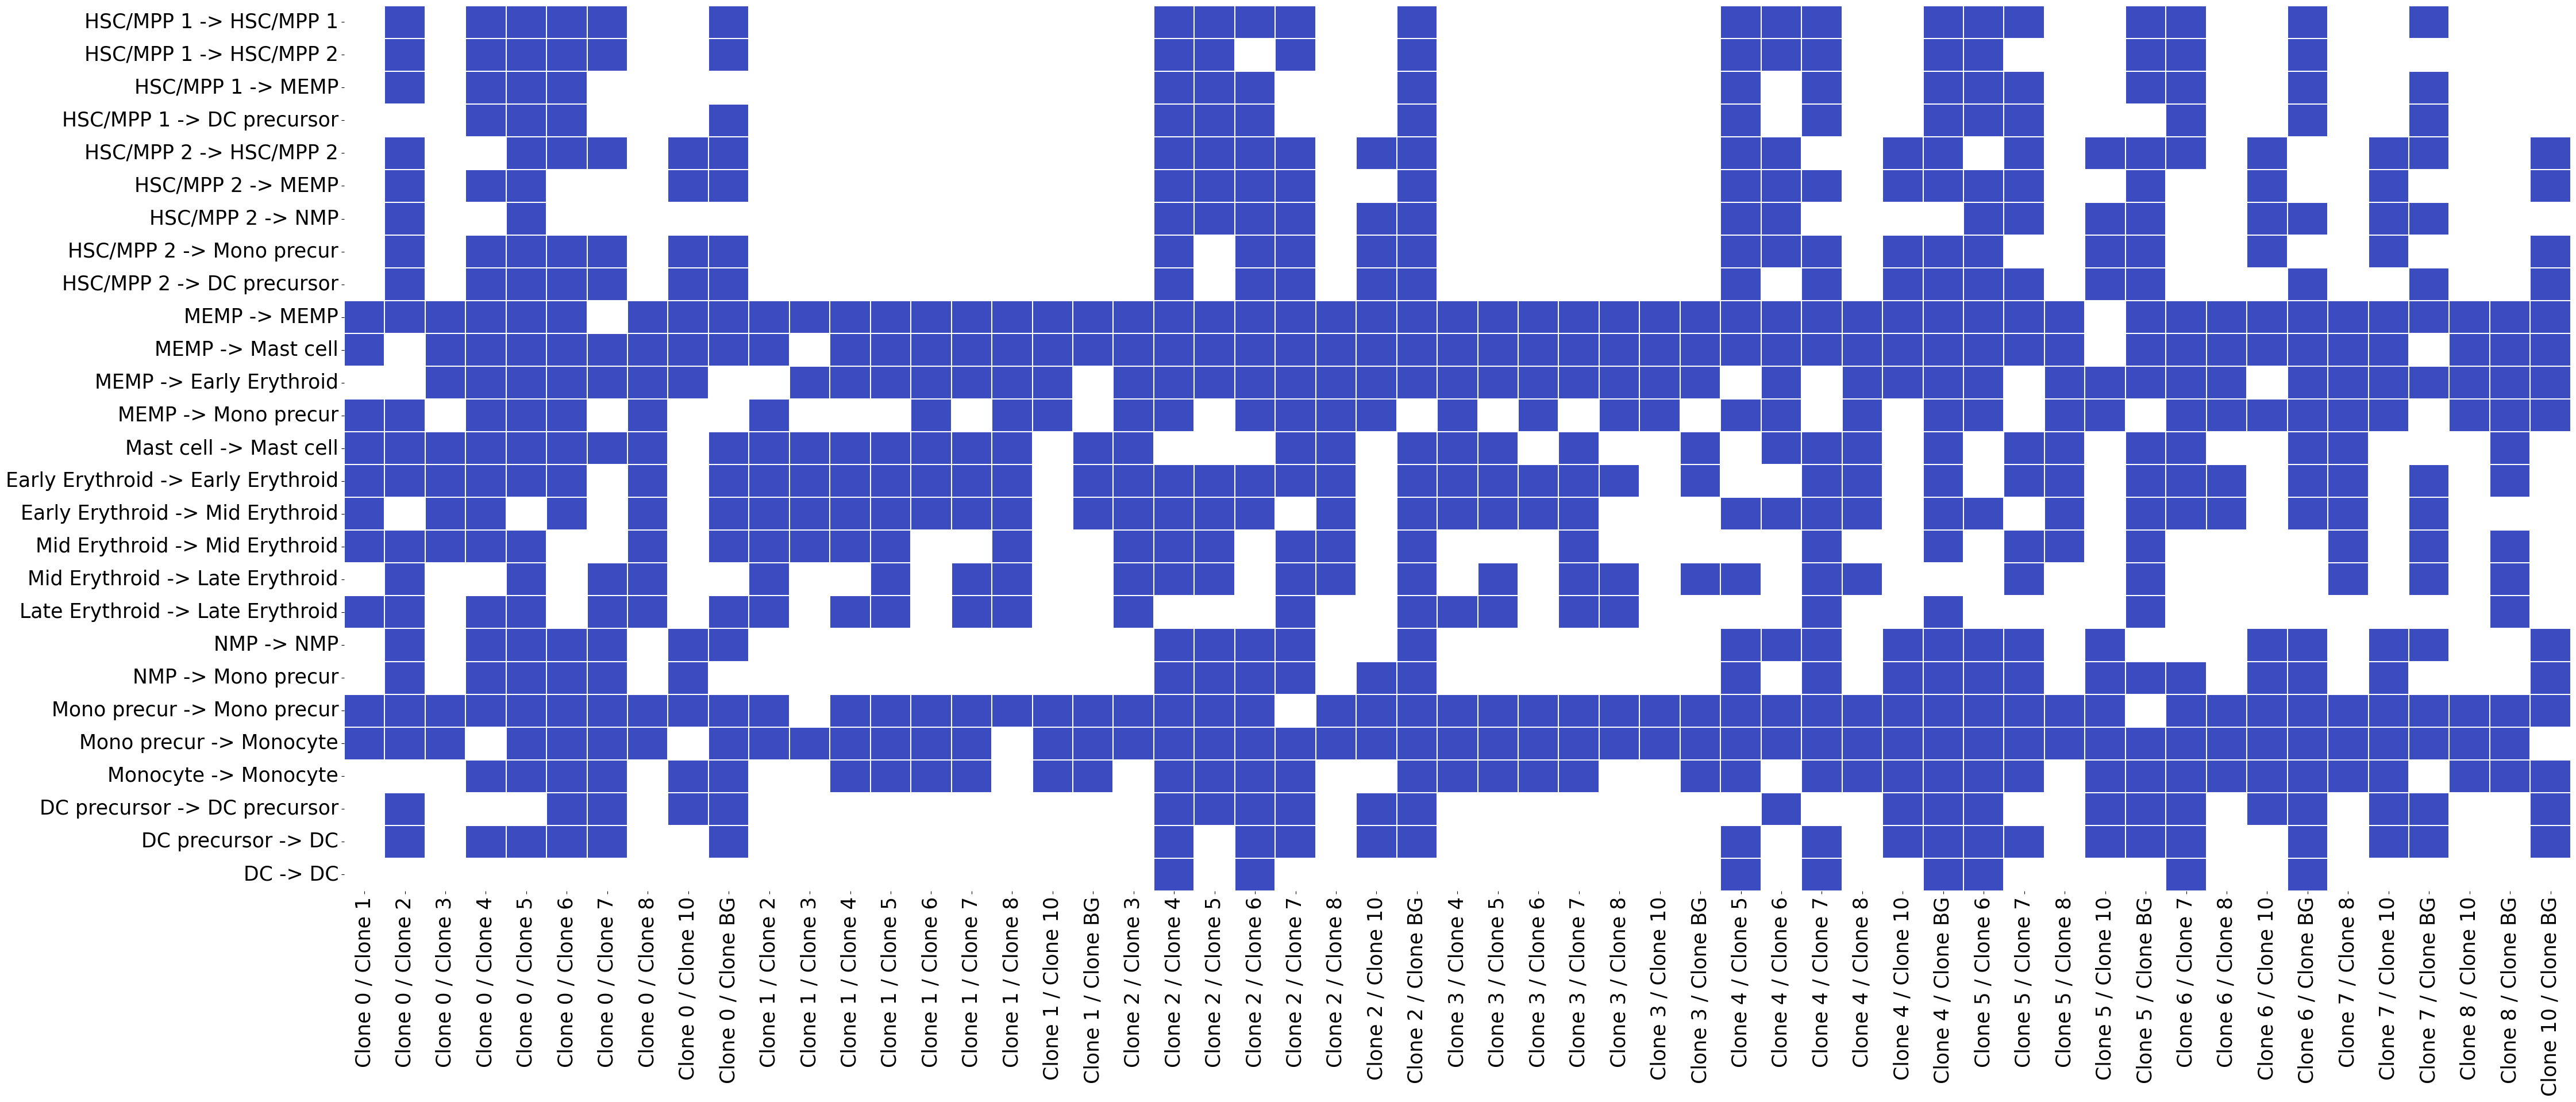

In [33]:
from itertools import product, combinations

combined = [adjusted_p_values, fold_correct]

anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))
graph = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['graphs']
), index_col=0)
np.fill_diagonal(graph.values, 1)
num_clones = model.N.shape[1]

cols = []
for pop1, pop2 in product(range(graph.shape[0]), range(graph.shape[1])):
    if graph.values[pop1][pop2] != 0:
        cols.append('{} -> {}'.format(anno['populations'].values[pop1], anno['populations'].values[pop2]))

index = []
for (c1, c2) in combinations(anno['clones'].values[:num_clones], 2):
    index.append(f'{c1} / {c2}')

combined[0][combined[0] > 0.01] = np.nan
combined[0][np.where(combined[1] < 0.1)] = np.nan
combined = -np.log10(combined[0])
combined[~np.isnan(combined)] = 0

df = pd.DataFrame(data=combined, index=cols, columns=index)
ax = sns.heatmap(df, annot=False, linewidths=.1, cmap='coolwarm', vmin=0, xticklabels=True, yticklabels=True, cbar=False)

plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(False)

fig = ax.get_figure()
fig.set_figwidth(50) 
fig.set_figheight(20) 

plt.savefig('pairwise_comparison_cordblood_day10.svg', bbox_inches='tight', transparent=True, dpi=300)

### Pairwise comparisons of all parameters (Cord Blood) Day 17

In [34]:
from clonaltrans.utils import get_boots_K_total
tpoint = torch.tensor([17.0]).to('cpu')

K_type = model.config['arch']['args']['K_type']
total_K, ref_K = get_boots_K_total(model_list, model, K_type, tpoint)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [35]:
from clonaltrans.utils import clone_rates_diff_test

p_values, adjusted_p_values, fold_correct = clone_rates_diff_test(model, total_K, correct_method='fdr_bh')
print (p_values.shape, adjusted_p_values.shape, fold_correct.shape)

(55, 12, 12) (27, 55) (27, 55)


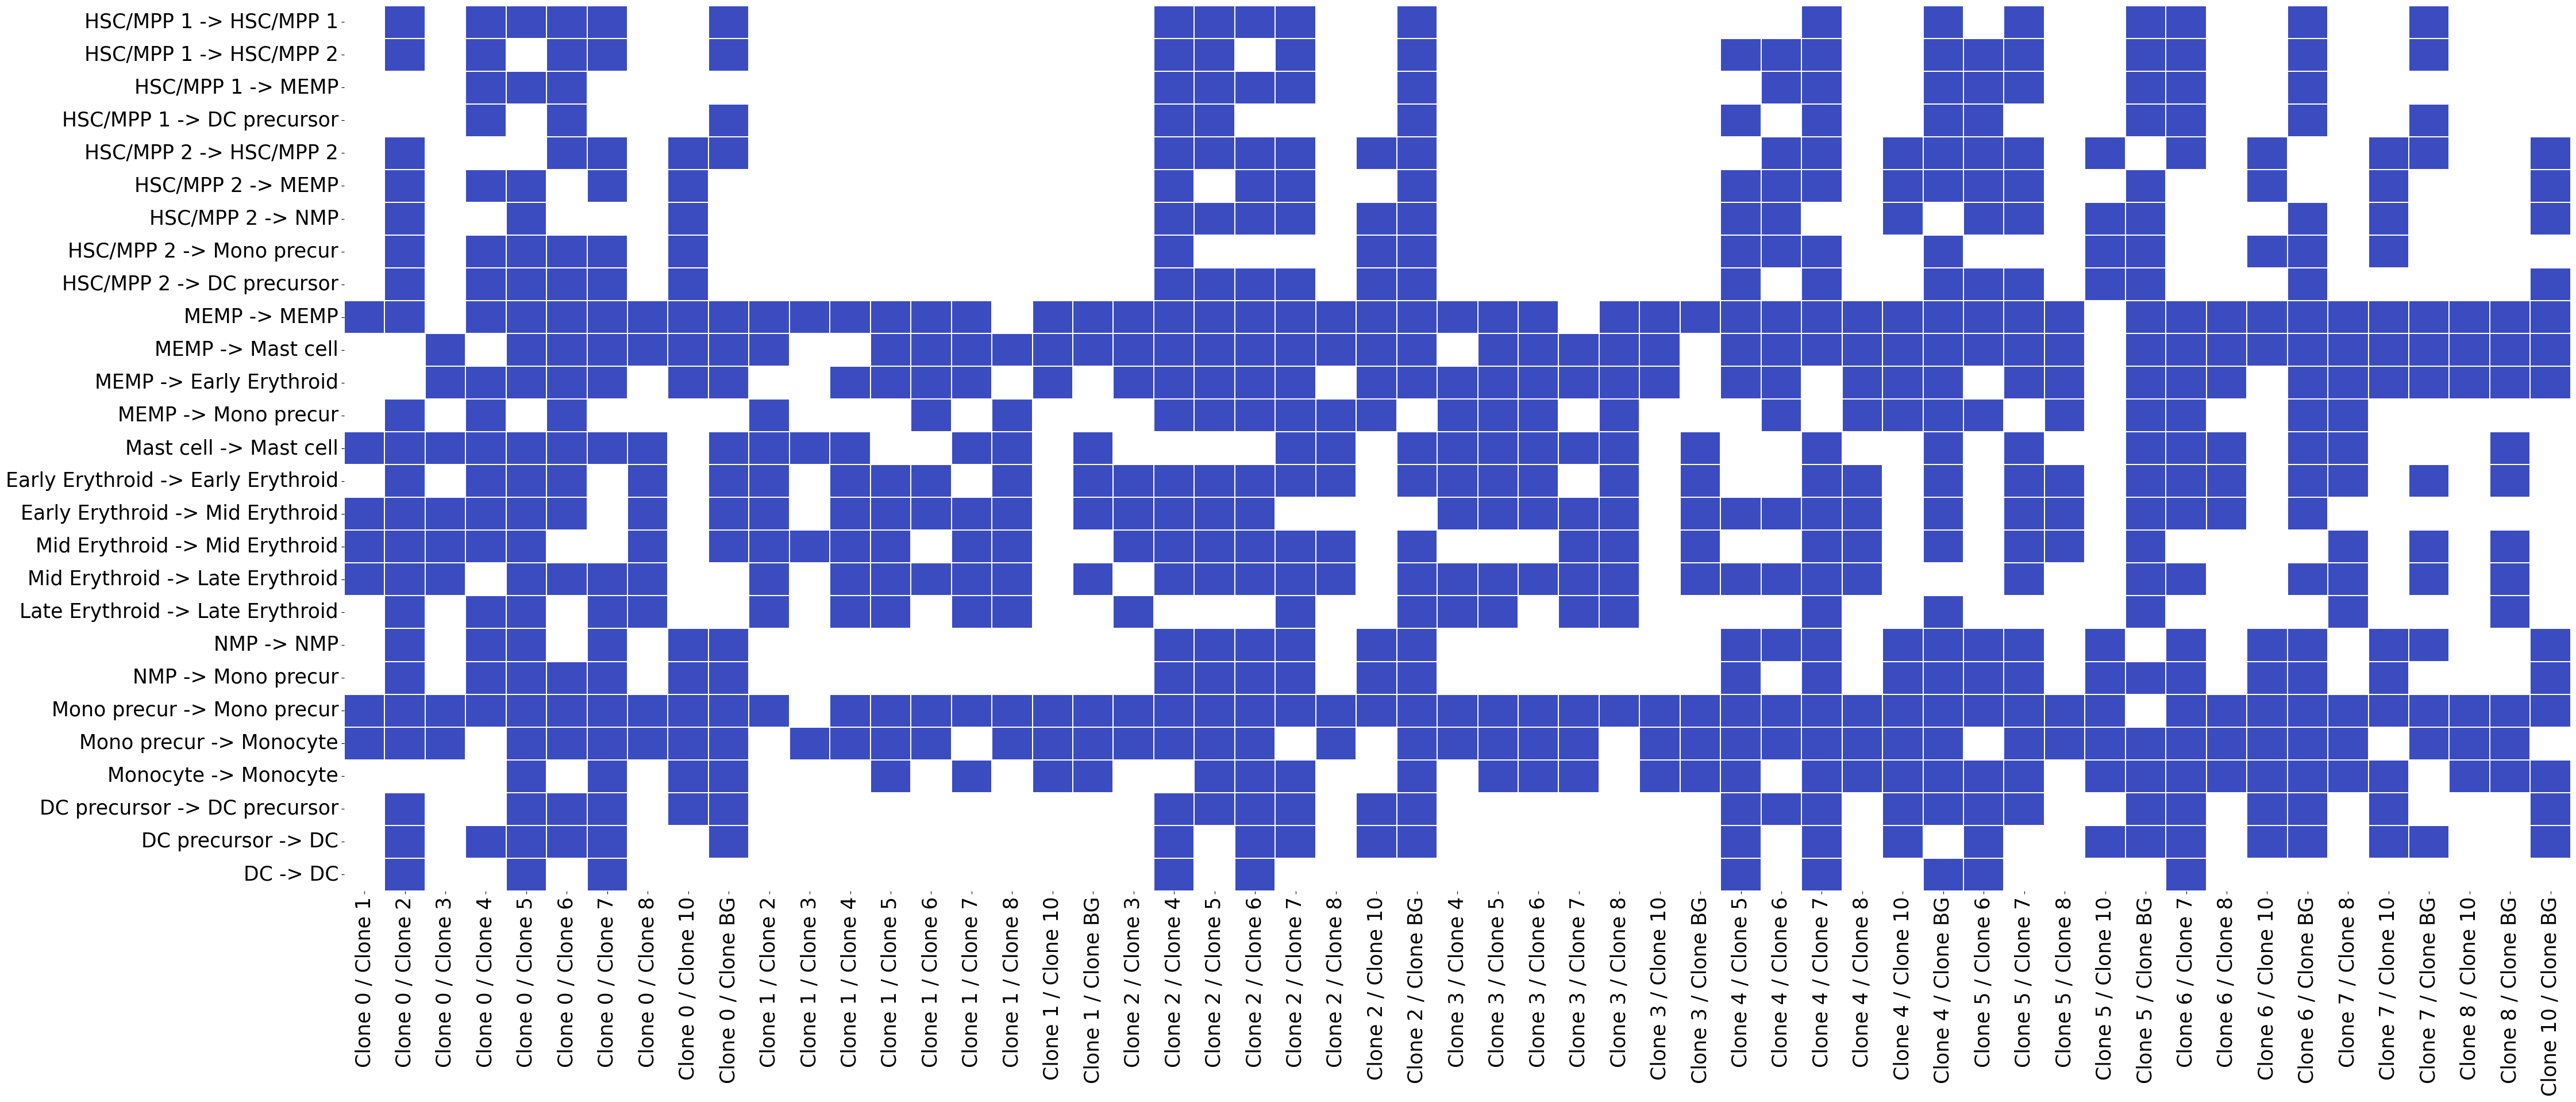

In [36]:
from itertools import product, combinations

combined = [adjusted_p_values, fold_correct]

anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))
graph = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['graphs']
), index_col=0)
np.fill_diagonal(graph.values, 1)
num_clones = model.N.shape[1]

cols = []
for pop1, pop2 in product(range(graph.shape[0]), range(graph.shape[1])):
    if graph.values[pop1][pop2] != 0:
        cols.append('{} -> {}'.format(anno['populations'].values[pop1], anno['populations'].values[pop2]))

index = []
for (c1, c2) in combinations(anno['clones'].values[:num_clones], 2):
    index.append(f'{c1} / {c2}')

combined[0][combined[0] > 0.01] = np.nan
combined[0][np.where(combined[1] < 0.1)] = np.nan
combined = -np.log10(combined[0])
combined[~np.isnan(combined)] = 0

df = pd.DataFrame(data=combined, index=cols, columns=index)
ax = sns.heatmap(df, annot=False, linewidths=.1, cmap='coolwarm', vmin=0, xticklabels=True, yticklabels=True, cbar=False)

plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(False)

fig = ax.get_figure()
fig.set_figwidth(50) 
fig.set_figheight(20) 

plt.savefig('pairwise_comparison_cordblood_day17.svg', bbox_inches='tight', transparent=True, dpi=300)

### Absolute number of divisions (Cord Blood) HSC/MPP 1

In [37]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/v1.2.0/checkpoints/CordBloodDynamicRates/1213_100718/model_last.pt'
model = torch.load(path, map_location='cpu')
device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [38]:
cluster_names = [
    'HSC/MPP 1', 'HSC/MPP 2', 'MEMP', 'Mast cell', 'Early Erythroid',
    'Mid Erythroid', 'Late Erythroid', 'NMP', 'Mono precur',
    'Monocyte', 'DC precursor', 'DC'
]

In [39]:
gillespie_dir='./trials/v1.2.0/checkpoints/CordBloodDynamicGillespie/1216_150034/models/'

In [57]:
anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))

In [41]:
from clonaltrans.pl import get_div_distribution
import copy

distributions = []

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('Clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        
        distribution, counts = get_div_distribution(gillespie_dir_clones, cluster_names, init_celltype=['HSC/MPP 1'])
        distributions.append(distribution)

In [49]:
for idx, clone in enumerate(distributions):
    distributions[idx] = {key: np.mean(value) if value else np.nan for key, value in clone.items()}

In [56]:
df = pd.DataFrame(distributions, index=anno['clones'].values[:-1]).round(3).T
df

,Clone 0,Clone 1,Clone 2,Clone 3,Clone 4,Clone 5,Clone 6,Clone 7,Clone 8,Clone 10,Clone BG
HSC/MPP 1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HSC/MPP 2,2.452,NaN,2.265,NaN,2.795,2.596,2.737,1.223,NaN,NaN,2.157
MEMP,2.823,NaN,1.888,NaN,1.902,11.557,3.076,3.384,NaN,NaN,3.977
Mast cell,4.873,NaN,2.803,NaN,2.452,NaN,4.186,4.673,NaN,NaN,5.250
Early Erythroid,10.371,NaN,5.557,NaN,3.918,13.697,NaN,10.583,NaN,NaN,11.917
Mid Erythroid,11.913,NaN,5.871,NaN,5.244,14.826,NaN,12.036,NaN,NaN,13.458
Late Erythroid,17.031,NaN,7.082,NaN,5.042,NaN,NaN,15.434,NaN,NaN,17.875
NMP,5.855,NaN,10.106,NaN,3.854,4.032,7.246,3.892,NaN,NaN,5.177
Mono precur,6.603,NaN,5.858,NaN,4.491,7.038,7.211,4.935,NaN,NaN,5.622
Monocyte,7.775,NaN,7.979,NaN,4.941,9.401,7.630,7.855,NaN,NaN,7.780


In [59]:
df.to_csv('table_of_abs_num_divisions_cordblood_hscmpp1.csv')

### Absolute number of divisions (Cord Blood) HSC/MPP 2

In [61]:
from clonaltrans.pl import get_div_distribution
import copy

distributions = []

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('Clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        
        distribution, counts = get_div_distribution(gillespie_dir_clones, cluster_names, init_celltype=['HSC/MPP 2'])
        distributions.append(distribution)

In [62]:
for idx, clone in enumerate(distributions):
    distributions[idx] = {key: np.mean(value) if value else np.nan for key, value in clone.items()}

In [63]:
df = pd.DataFrame(distributions, index=anno['clones'].values[:-1]).round(3).T
df

,Clone 0,Clone 1,Clone 2,Clone 3,Clone 4,Clone 5,Clone 6,Clone 7,Clone 8,Clone 10,Clone BG
HSC/MPP 1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HSC/MPP 2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MEMP,2.771,NaN,NaN,NaN,4.453,NaN,2.601,4.108,NaN,NaN,3.939
Mast cell,4.667,NaN,NaN,NaN,6.400,NaN,3.908,5.281,NaN,NaN,5.235
Early Erythroid,9.625,NaN,NaN,NaN,9.220,NaN,NaN,11.260,NaN,NaN,11.439
Mid Erythroid,10.763,NaN,NaN,NaN,11.713,NaN,NaN,12.846,NaN,NaN,12.415
Late Erythroid,15.481,NaN,NaN,NaN,13.986,NaN,NaN,15.492,NaN,NaN,16.000
NMP,2.981,NaN,NaN,NaN,1.809,0.153,6.177,2.801,NaN,2.841,2.756
Mono precur,3.228,NaN,NaN,NaN,3.553,0.599,6.245,3.663,NaN,4.138,3.607
Monocyte,4.673,NaN,NaN,NaN,4.532,1.678,6.598,6.558,NaN,5.373,4.888


In [64]:
df.to_csv('table_of_abs_num_divisions_cordblood_hscmpp2.csv')

### Absolute number of divisions (Cord Blood) MEMP

In [65]:
from clonaltrans.pl import get_div_distribution
import copy

distributions = []

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('Clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        
        distribution, counts = get_div_distribution(gillespie_dir_clones, cluster_names, init_celltype=['MEMP'])
        distributions.append(distribution)

In [66]:
for idx, clone in enumerate(distributions):
    distributions[idx] = {key: np.mean(value) if value else np.nan for key, value in clone.items()}

In [67]:
df = pd.DataFrame(distributions, index=anno['clones'].values[:-1]).round(3).T
df

,Clone 0,Clone 1,Clone 2,Clone 3,Clone 4,Clone 5,Clone 6,Clone 7,Clone 8,Clone 10,Clone BG
HSC/MPP 1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HSC/MPP 2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MEMP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mast cell,2.363,4.849,NaN,2.687,0.875,NaN,NaN,NaN,3.066,NaN,1.330
Early Erythroid,8.191,2.648,NaN,6.582,1.857,NaN,NaN,NaN,5.544,NaN,9.139
Mid Erythroid,10.037,5.302,NaN,8.648,2.182,NaN,NaN,NaN,8.428,NaN,11.043
Late Erythroid,16.308,12.651,NaN,12.840,2.000,NaN,NaN,NaN,NaN,NaN,17.046
NMP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mono precur,17.000,9.679,NaN,9.677,1.923,NaN,NaN,NaN,NaN,NaN,11.474
Monocyte,15.333,13.790,NaN,11.183,2.385,NaN,NaN,NaN,NaN,NaN,12.363


In [68]:
df.to_csv('table_of_abs_num_divisions_cordblood_memp.csv')

### Absolute number of divisions (Cord Blood) NMP

In [69]:
from clonaltrans.pl import get_div_distribution
import copy

distributions = []

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('Clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        
        distribution, counts = get_div_distribution(gillespie_dir_clones, cluster_names, init_celltype=['NMP'])
        distributions.append(distribution)

In [70]:
for idx, clone in enumerate(distributions):
    distributions[idx] = {key: np.mean(value) if value else np.nan for key, value in clone.items()}

In [71]:
df = pd.DataFrame(distributions, index=anno['clones'].values[:-1]).round(3).T
df

,Clone 0,Clone 1,Clone 2,Clone 3,Clone 4,Clone 5,Clone 6,Clone 7,Clone 8,Clone 10,Clone BG
HSC/MPP 1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HSC/MPP 2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MEMP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mast cell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Early Erythroid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mid Erythroid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Late Erythroid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NMP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mono precur,2.654,NaN,NaN,NaN,1.869,0.557,2.459,NaN,NaN,3.059,3.251
Monocyte,5.739,NaN,NaN,NaN,2.789,1.874,3.563,NaN,NaN,4.653,4.492


In [72]:
df.to_csv('table_of_abs_num_divisions_cordblood_nmp.csv')

### Pairwise comparison of all divisions (Cord Blood) HSC/MPP 1

In [73]:
from clonaltrans.pl import get_div_distribution
import copy

distributions = []

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('Clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        
        distribution, counts = get_div_distribution(gillespie_dir_clones, cluster_names, init_celltype=['HSC/MPP 1'])
        distributions.append(distribution)

In [79]:
cluster_names = [
    'HSC/MPP 1', 'HSC/MPP 2', 'MEMP', 'Mast cell', 'Early Erythroid',
    'Mid Erythroid', 'Late Erythroid', 'NMP', 'Mono precur',
    'Monocyte', 'DC precursor', 'DC'
]

In [89]:
import scipy.stats as stats
p_values = []
checked = []

for cluster in cluster_names:
    p_values.append([])

    for idx, clone_ref in enumerate(anno['clones'].values[:-1]):
        for idy, clone_test in enumerate(anno['clones'].values[:-1]):
            x = distributions[idx][cluster]
            y = distributions[idy][cluster]

            if idx != idy and idy >= idx: 

                if len(x) > 5 and len(y) > 5:
                    _, shapiro_p_c1 = stats.shapiro(x)
                    _, shapiro_p_c2 = stats.shapiro(y)

                    if shapiro_p_c1 > 0.05 and shapiro_p_c2 > 0.05:
                        _, paired_p = stats.ttest_ind(x, y) 
                    else:
                        _, paired_p = stats.mannwhitneyu(x, y)
                    
                    p_values[-1].append(paired_p)
                
                else:
                    p_values[-1].append(np.nan)

p_values = np.array(p_values)

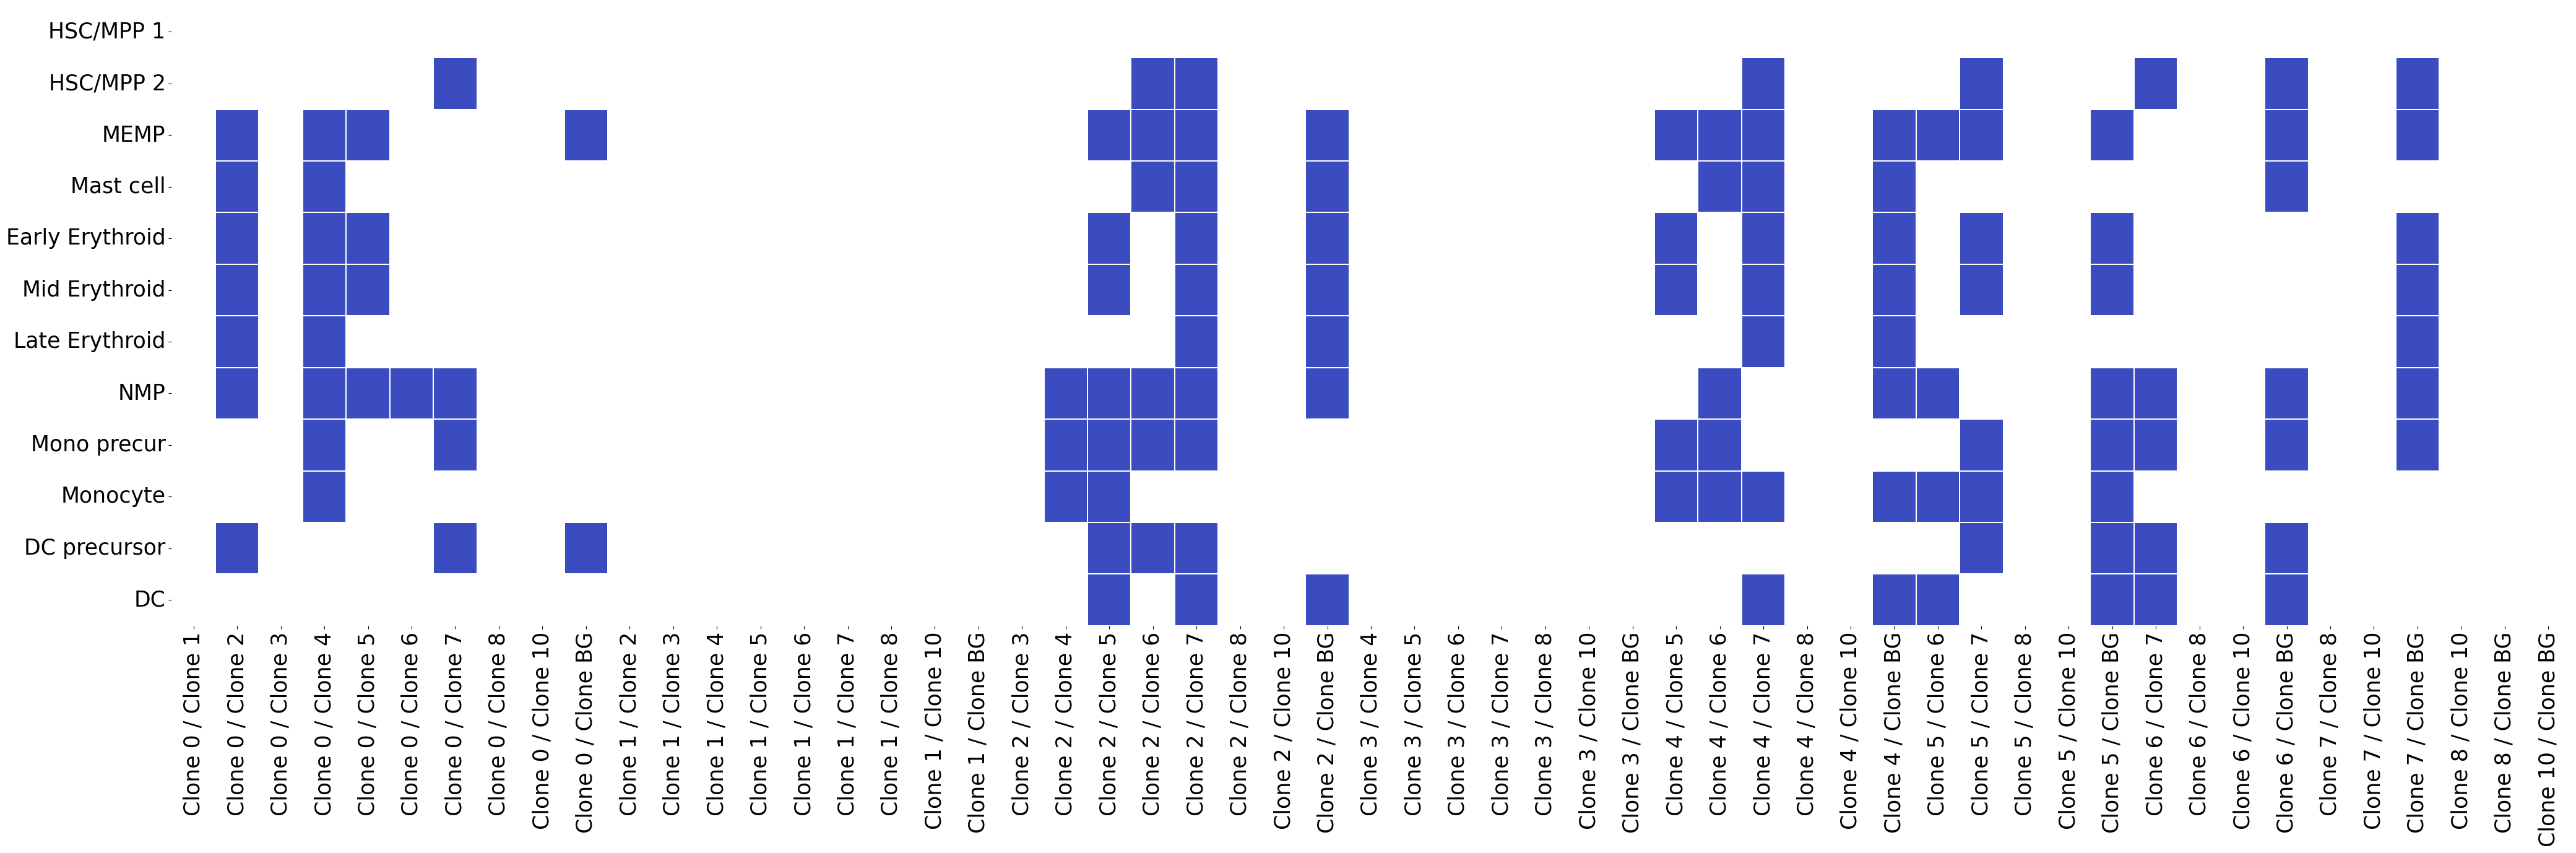

In [98]:
from itertools import product, combinations

combined = p_values

anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))

num_clones = model.N.shape[1]

index = []
for (c1, c2) in combinations(anno['clones'].values[:num_clones], 2):
    index.append(f'{c1} / {c2}')

combined[combined > 0.01] = np.nan
combined = -np.log10(combined)
combined[~np.isnan(combined)] = 0

df = pd.DataFrame(data=combined, index=cluster_names, columns=index)
ax = sns.heatmap(df, annot=False, linewidths=.1, cmap='coolwarm', vmin=0, xticklabels=True, yticklabels=True, cbar=False)

plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(False)

fig = ax.get_figure()
fig.set_figwidth(50) 
fig.set_figheight(13) 

plt.savefig('pairwise_divisions_cordblood_hscmpp1.svg', bbox_inches='tight', transparent=True, dpi=300)

### Pairwise comparison of all divisions (Cord Blood) HSC/MPP 2

In [99]:
from clonaltrans.pl import get_div_distribution
import copy

distributions = []

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('Clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        
        distribution, counts = get_div_distribution(gillespie_dir_clones, cluster_names, init_celltype=['HSC/MPP 2'])
        distributions.append(distribution)

In [100]:
import scipy.stats as stats
p_values = []
checked = []

for cluster in cluster_names:
    p_values.append([])

    for idx, clone_ref in enumerate(anno['clones'].values[:-1]):
        for idy, clone_test in enumerate(anno['clones'].values[:-1]):
            x = distributions[idx][cluster]
            y = distributions[idy][cluster]

            if idx != idy and idy >= idx: 

                if len(x) > 5 and len(y) > 5:
                    _, shapiro_p_c1 = stats.shapiro(x)
                    _, shapiro_p_c2 = stats.shapiro(y)

                    if shapiro_p_c1 > 0.05 and shapiro_p_c2 > 0.05:
                        _, paired_p = stats.ttest_ind(x, y) 
                    else:
                        _, paired_p = stats.mannwhitneyu(x, y)
                    
                    p_values[-1].append(paired_p)
                
                else:
                    p_values[-1].append(np.nan)

p_values = np.array(p_values)

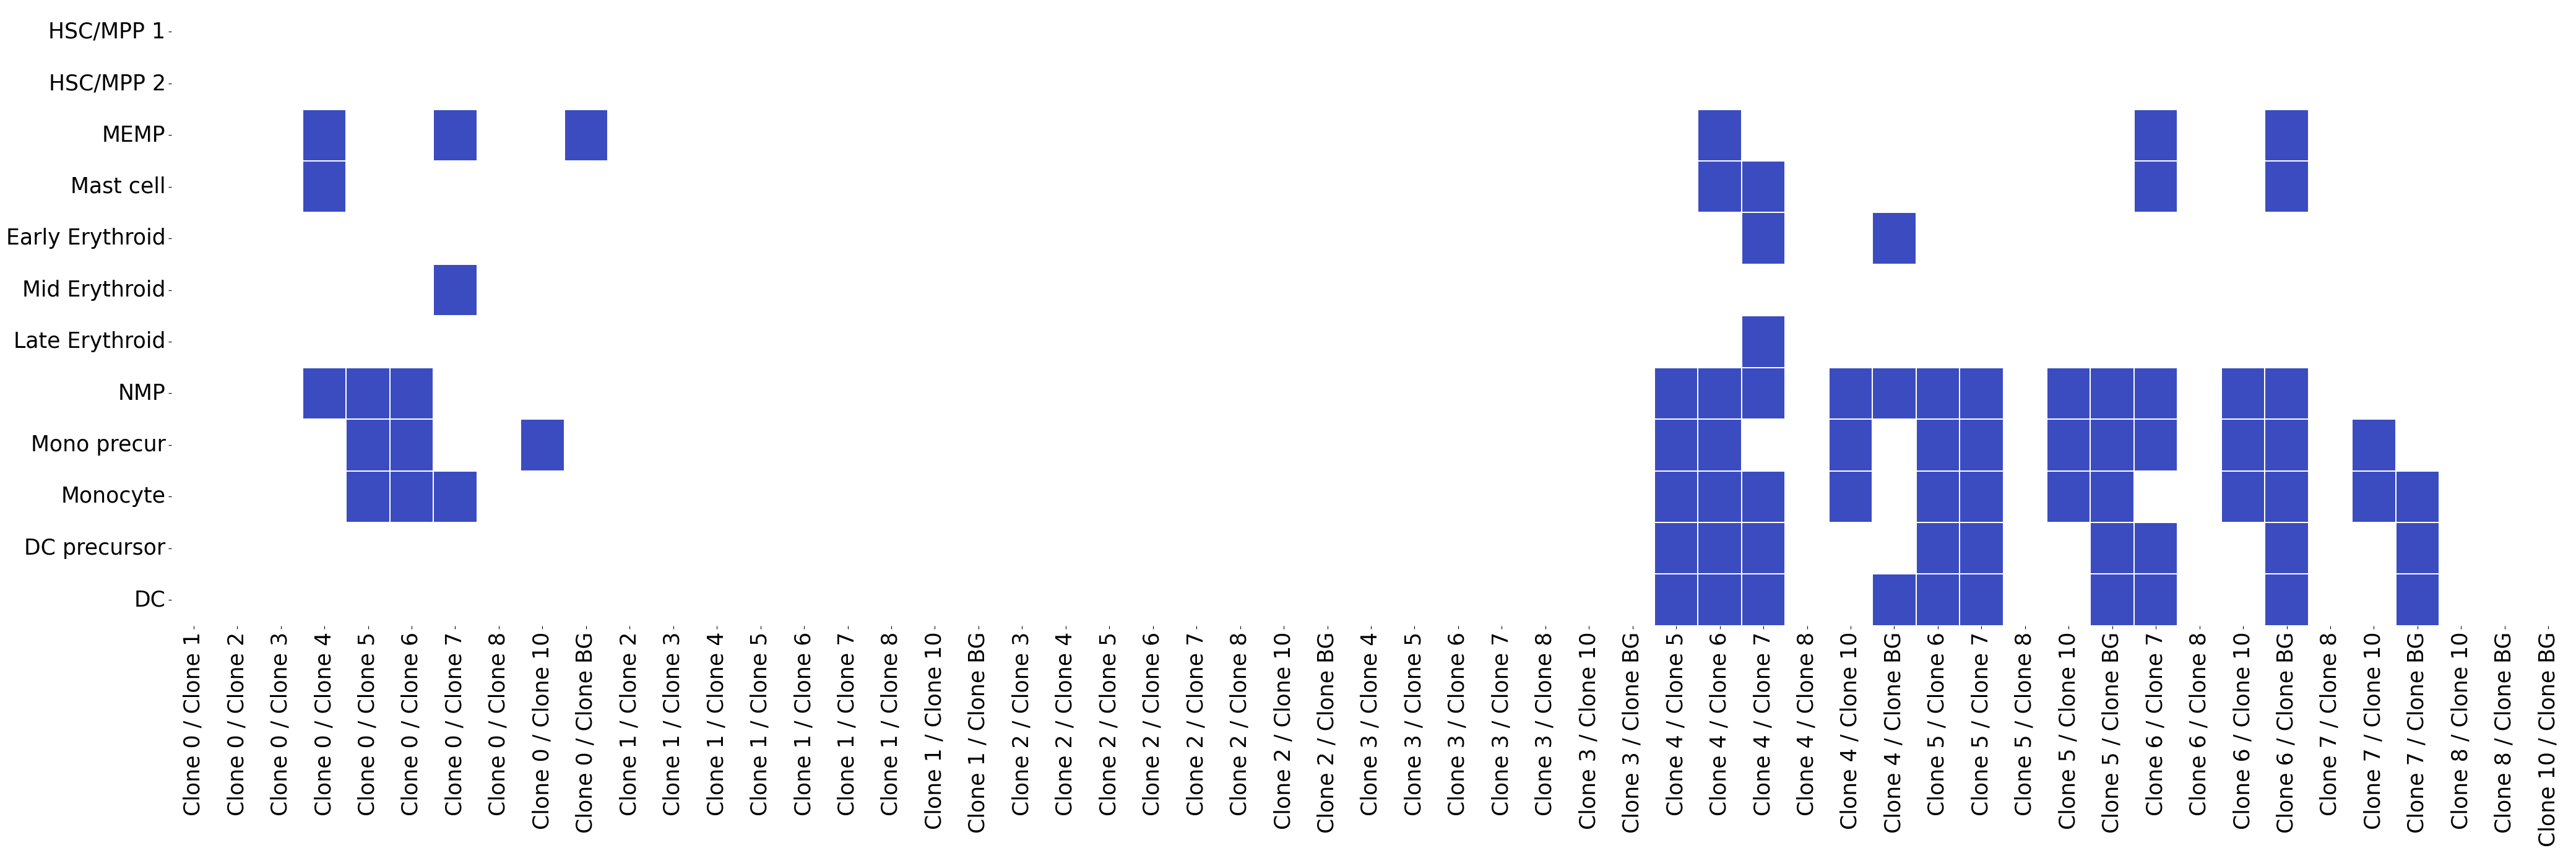

In [101]:
from itertools import product, combinations

combined = p_values

anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))

num_clones = model.N.shape[1]

index = []
for (c1, c2) in combinations(anno['clones'].values[:num_clones], 2):
    index.append(f'{c1} / {c2}')

combined[combined > 0.01] = np.nan
combined = -np.log10(combined)
combined[~np.isnan(combined)] = 0

df = pd.DataFrame(data=combined, index=cluster_names, columns=index)
ax = sns.heatmap(df, annot=False, linewidths=.1, cmap='coolwarm', vmin=0, xticklabels=True, yticklabels=True, cbar=False)

plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(False)

fig = ax.get_figure()
fig.set_figwidth(50) 
fig.set_figheight(13) 

plt.savefig('pairwise_divisions_cordblood_hscmpp2.svg', bbox_inches='tight', transparent=True, dpi=300)

### Pairwise comparison of all divisions (Cord Blood) MEMP

In [102]:
from clonaltrans.pl import get_div_distribution
import copy

distributions = []

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('Clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        
        distribution, counts = get_div_distribution(gillespie_dir_clones, cluster_names, init_celltype=['MEMP'])
        distributions.append(distribution)

In [103]:
import scipy.stats as stats
p_values = []
checked = []

for cluster in cluster_names:
    p_values.append([])

    for idx, clone_ref in enumerate(anno['clones'].values[:-1]):
        for idy, clone_test in enumerate(anno['clones'].values[:-1]):
            x = distributions[idx][cluster]
            y = distributions[idy][cluster]

            if idx != idy and idy >= idx: 

                if len(x) > 5 and len(y) > 5:
                    _, shapiro_p_c1 = stats.shapiro(x)
                    _, shapiro_p_c2 = stats.shapiro(y)

                    if shapiro_p_c1 > 0.05 and shapiro_p_c2 > 0.05:
                        _, paired_p = stats.ttest_ind(x, y) 
                    else:
                        _, paired_p = stats.mannwhitneyu(x, y)
                    
                    p_values[-1].append(paired_p)
                
                else:
                    p_values[-1].append(np.nan)

p_values = np.array(p_values)

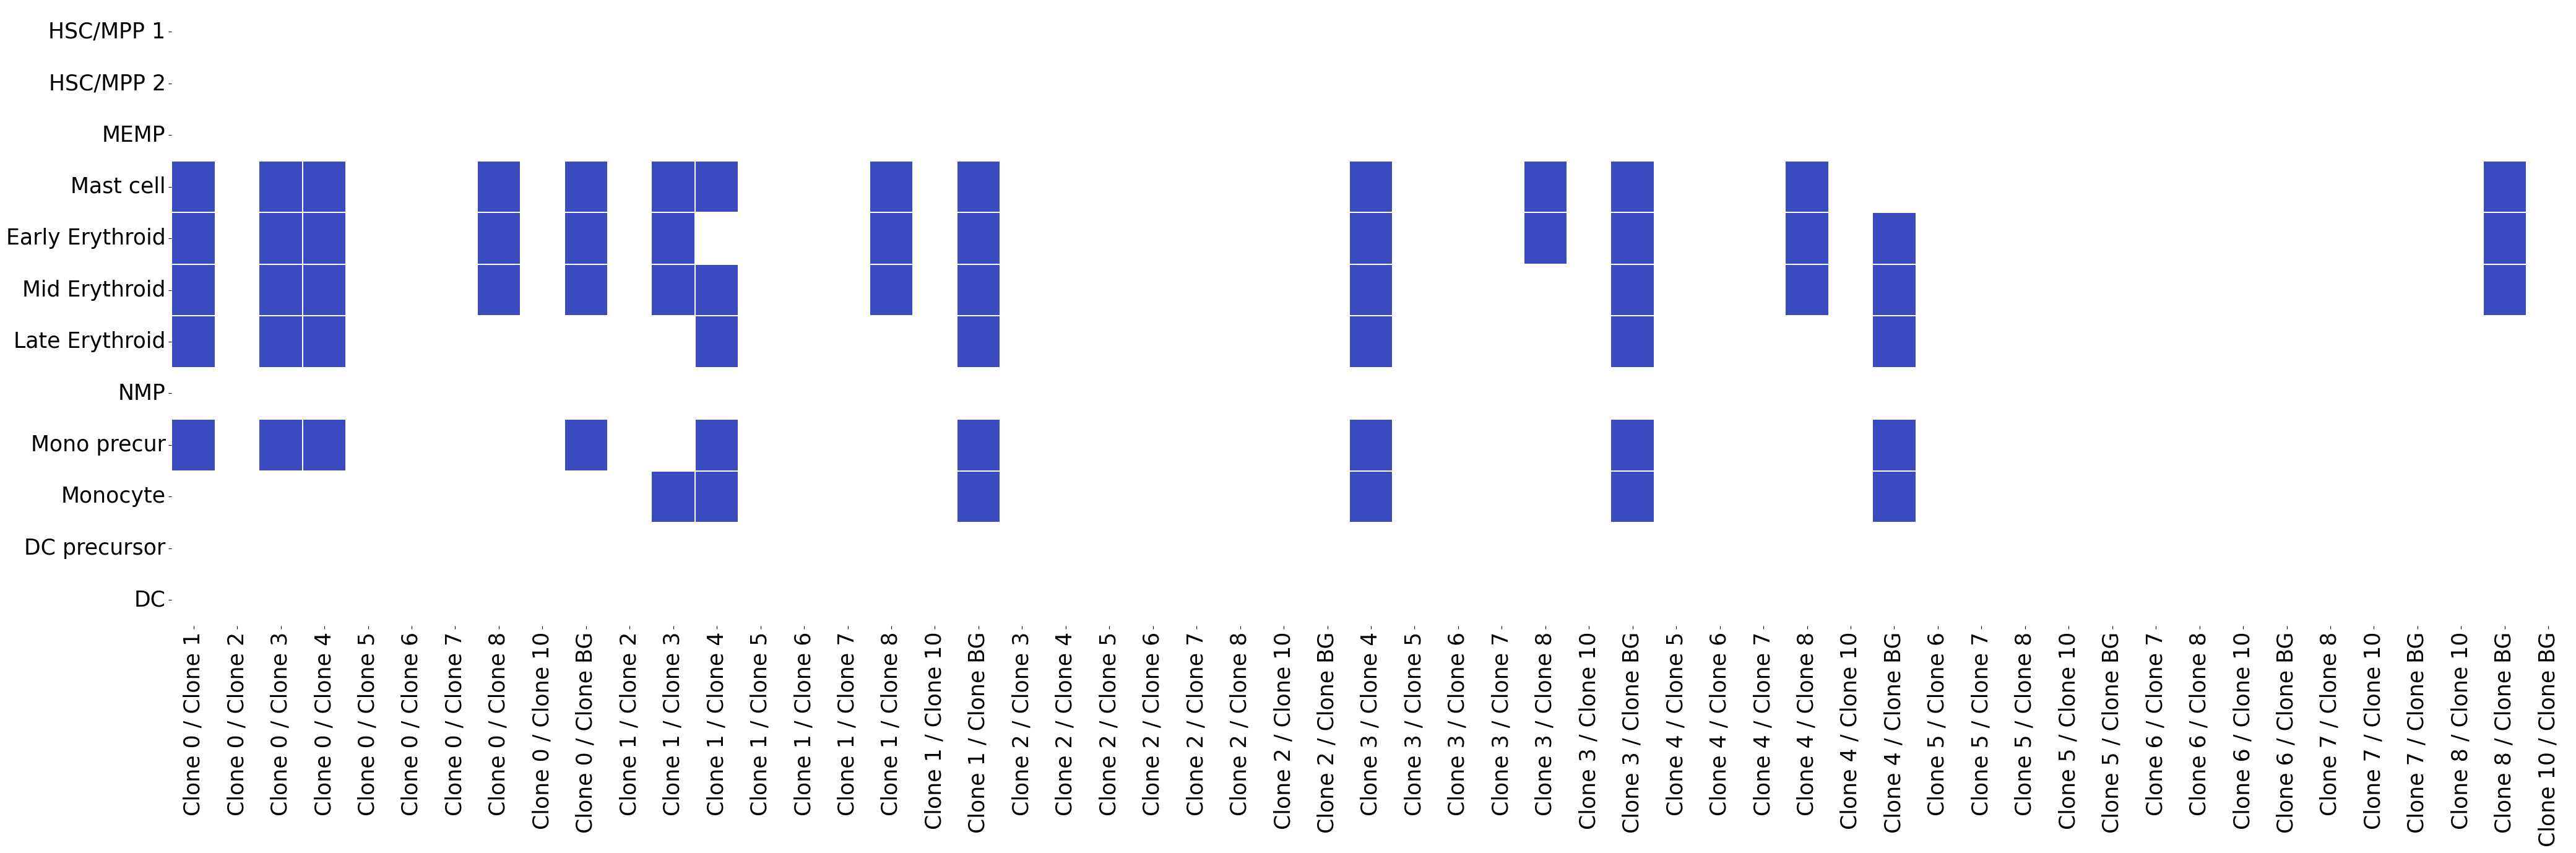

In [104]:
from itertools import product, combinations

combined = p_values

anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))

num_clones = model.N.shape[1]

index = []
for (c1, c2) in combinations(anno['clones'].values[:num_clones], 2):
    index.append(f'{c1} / {c2}')

combined[combined > 0.01] = np.nan
combined = -np.log10(combined)
combined[~np.isnan(combined)] = 0

df = pd.DataFrame(data=combined, index=cluster_names, columns=index)
ax = sns.heatmap(df, annot=False, linewidths=.1, cmap='coolwarm', vmin=0, xticklabels=True, yticklabels=True, cbar=False)

plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(False)

fig = ax.get_figure()
fig.set_figwidth(50) 
fig.set_figheight(13) 

plt.savefig('pairwise_divisions_cordblood_memp.svg', bbox_inches='tight', transparent=True, dpi=300)

### Pairwise comparison of all divisions (Cord Blood) NMP

In [105]:
from clonaltrans.pl import get_div_distribution
import copy

distributions = []

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('Clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        
        distribution, counts = get_div_distribution(gillespie_dir_clones, cluster_names, init_celltype=['NMP'])
        distributions.append(distribution)

In [106]:
import scipy.stats as stats
p_values = []
checked = []

for cluster in cluster_names:
    p_values.append([])

    for idx, clone_ref in enumerate(anno['clones'].values[:-1]):
        for idy, clone_test in enumerate(anno['clones'].values[:-1]):
            x = distributions[idx][cluster]
            y = distributions[idy][cluster]

            if idx != idy and idy >= idx: 

                if len(x) > 5 and len(y) > 5:
                    _, shapiro_p_c1 = stats.shapiro(x)
                    _, shapiro_p_c2 = stats.shapiro(y)

                    if shapiro_p_c1 > 0.05 and shapiro_p_c2 > 0.05:
                        _, paired_p = stats.ttest_ind(x, y) 
                    else:
                        _, paired_p = stats.mannwhitneyu(x, y)
                    
                    p_values[-1].append(paired_p)
                
                else:
                    p_values[-1].append(np.nan)

p_values = np.array(p_values)

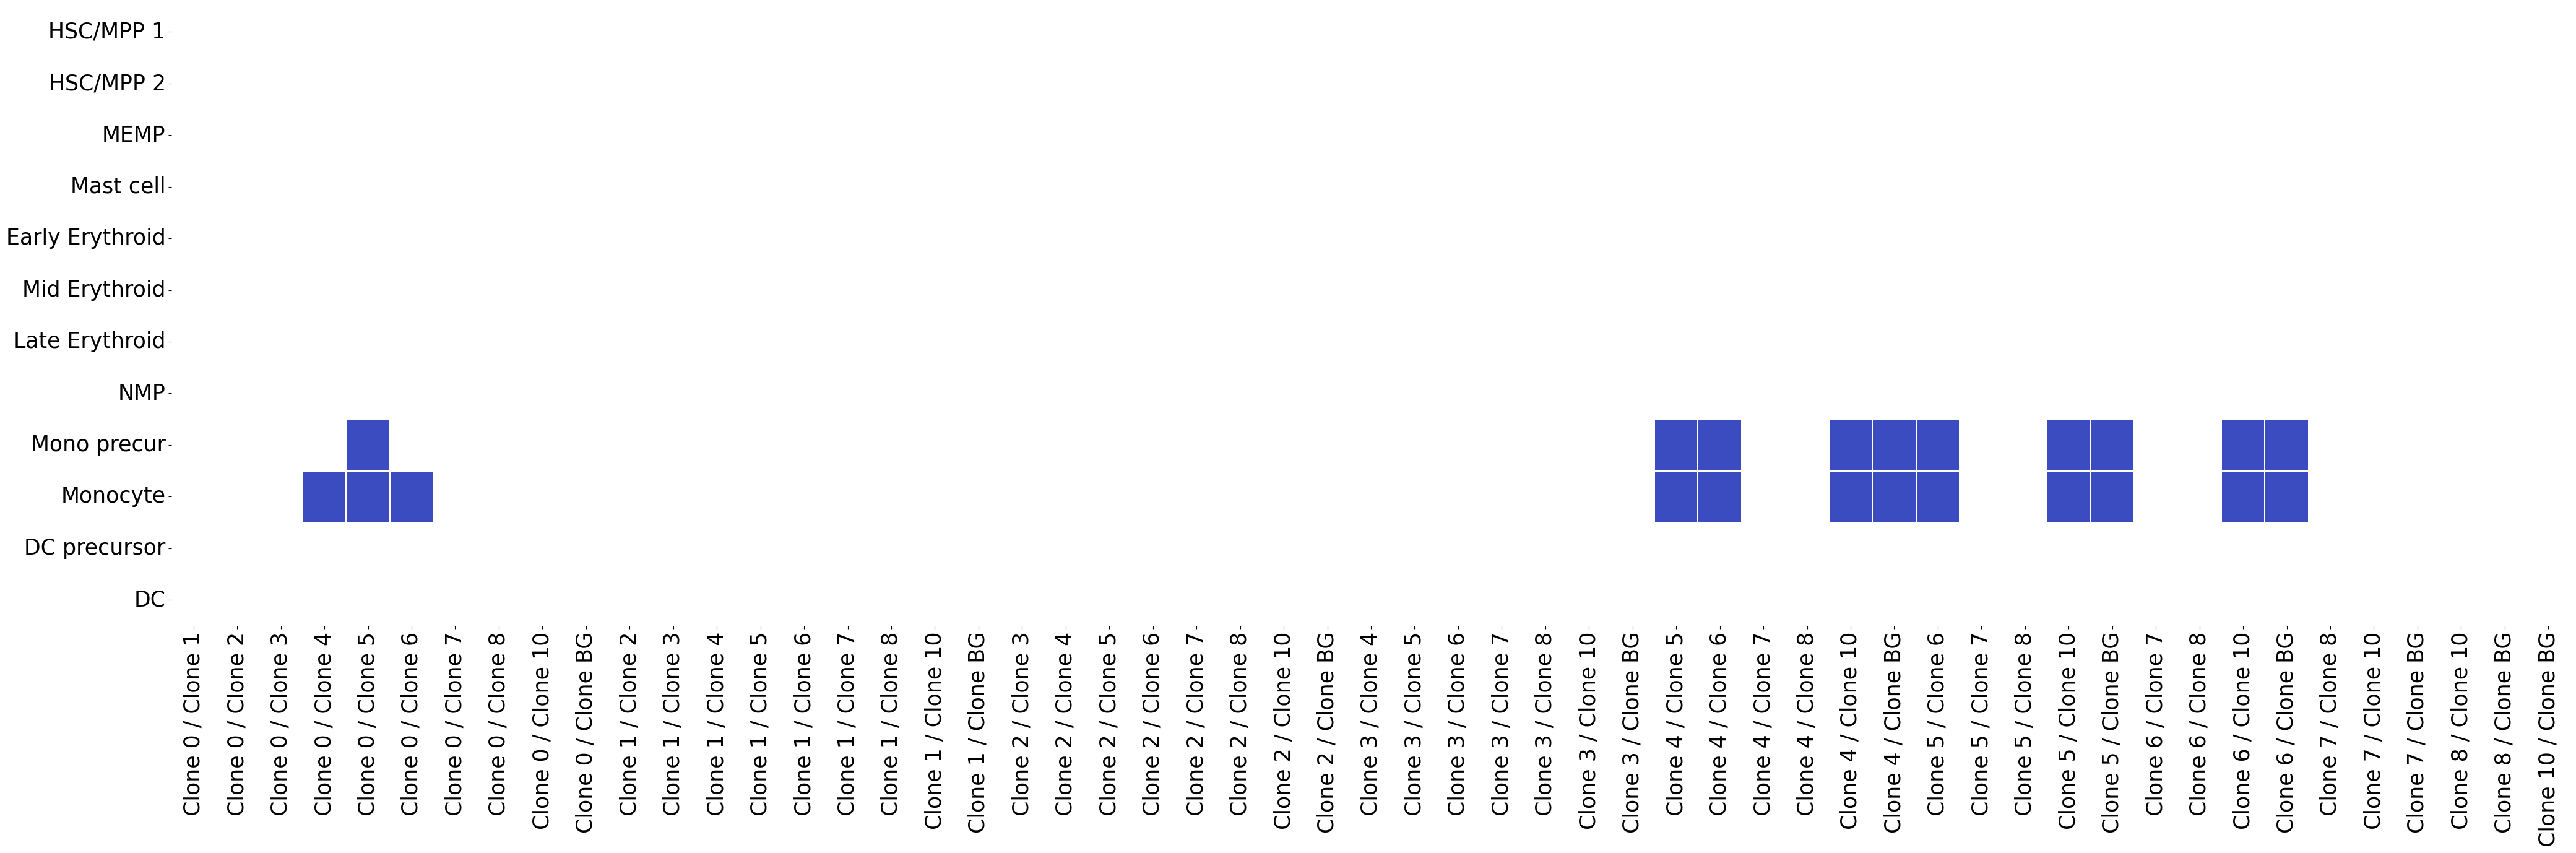

In [107]:
from itertools import product, combinations

combined = p_values

anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))

num_clones = model.N.shape[1]

index = []
for (c1, c2) in combinations(anno['clones'].values[:num_clones], 2):
    index.append(f'{c1} / {c2}')

combined[combined > 0.01] = np.nan
combined = -np.log10(combined)
combined[~np.isnan(combined)] = 0

df = pd.DataFrame(data=combined, index=cluster_names, columns=index)
ax = sns.heatmap(df, annot=False, linewidths=.1, cmap='coolwarm', vmin=0, xticklabels=True, yticklabels=True, cbar=False)

plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(False)

fig = ax.get_figure()
fig.set_figwidth(50) 
fig.set_figheight(13) 

plt.savefig('pairwise_divisions_cordblood_nmp.svg', bbox_inches='tight', transparent=True, dpi=300)